In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)

print(response.status_code)

200


In [5]:
jobs = soup.find_all("div", class_="card-content")
print(len(jobs))

100


In [6]:
jobs = soup.find_all("div", class_="card-content")

print("Total jobs found:", len(jobs))

Total jobs found: 100


In [7]:
job_list = []

for job in jobs:
    title = job.find("h2", class_="title").text.strip()
    company = job.find("h3", class_="company").text.strip()
    location = job.find("p", class_="location").text.strip()

    job_list.append([title, company, location])

In [8]:
df = pd.DataFrame(job_list, columns=["Title", "Company", "Location"])

df.head()

,Title,Company,Location
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA"
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA"
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA"
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP"
4,Product manager,Ramirez Inc,"North Jamieview, AP"


In [9]:
df.to_csv("jobs_data.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [10]:
print("Total Jobs:", len(df))

print("\nTop Companies:")
print(df["Company"].value_counts().head())

Total Jobs: 100

Top Companies:
Company
Garcia PLC                    2
Vasquez-Davidson              1
Payne, Roberts and Davis      1
Jackson, Chambers and Levy    1
Savage-Bradley                1
Name: count, dtype: int64


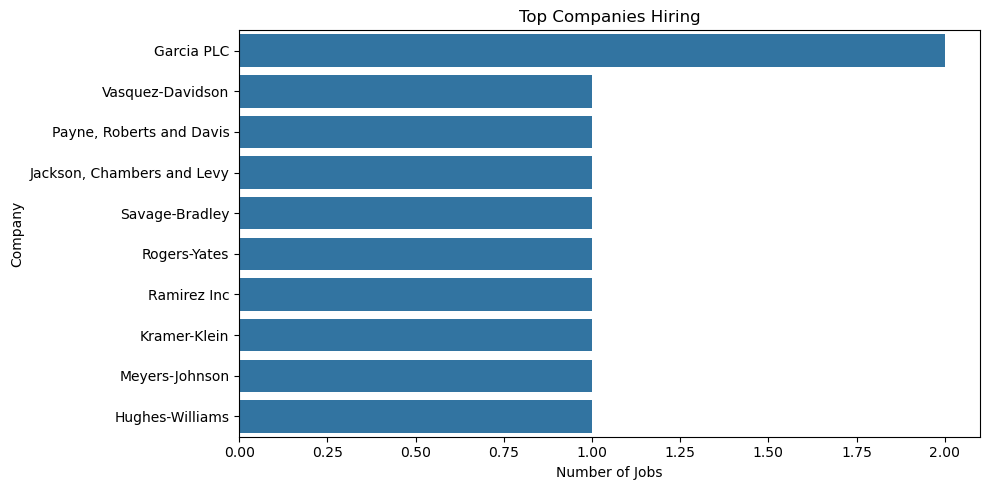

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

top_companies = df["Company"].value_counts().head(10)

sns.barplot(x=top_companies.values, y=top_companies.index)

plt.title("Top Companies Hiring")
plt.xlabel("Number of Jobs")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150)
plt.show()

In [12]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.head()

,Title,Company,Location
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA"
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA"
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA"
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP"
4,Product manager,Ramirez Inc,"North Jamieview, AP"


In [13]:
df["Company"].value_counts().head(10)

Company
Garcia PLC                    2
Vasquez-Davidson              1
Payne, Roberts and Davis      1
Jackson, Chambers and Levy    1
Savage-Bradley                1
Rogers-Yates                  1
Ramirez Inc                   1
Kramer-Klein                  1
Meyers-Johnson                1
Hughes-Williams               1
Name: count, dtype: int64

In [14]:
df["Location"].value_counts().head(10)

Location
Stewartbury, AA          1
Christopherville, AA     1
Port Ericaburgh, AA      1
East Seanview, AP        1
North Jamieview, AP      1
Davidville, AP           1
South Christopher, AE    1
Port Jonathan, AE        1
Osbornetown, AE          1
Scotttown, AP            1
Name: count, dtype: int64

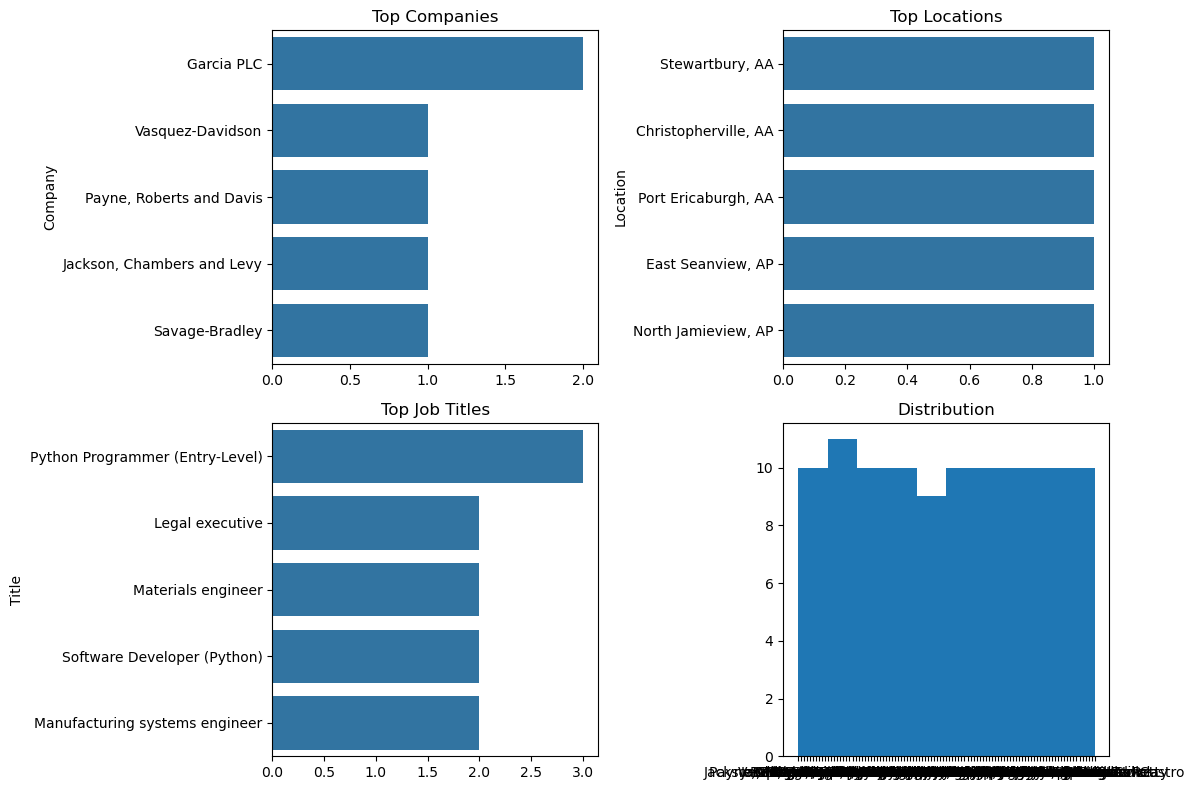

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top companies
top_companies = df["Company"].value_counts().head(5)
sns.barplot(x=top_companies.values, y=top_companies.index, ax=axes[0,0])
axes[0,0].set_title("Top Companies")

# Top locations
top_locations = df["Location"].value_counts().head(5)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0,1])
axes[0,1].set_title("Top Locations")

# Job titles
top_titles = df["Title"].value_counts().head(5)
sns.barplot(x=top_titles.values, y=top_titles.index, ax=axes[1,0])
axes[1,0].set_title("Top Job Titles")

# Job count chart
axes[1,1].hist(df["Company"])
axes[1,1].set_title("Distribution")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150)
plt.show()

In [16]:
df.to_csv("final_jobs_data.csv", index=False)
print("Final dataset saved!")

Final dataset saved!
